Original Hankel Matrix Shape: (8, 5000)
Shape of U matrix: (8, 8)
 Shape of s matrix: (8,) 
 Shape of V matrix: (8, 5000)


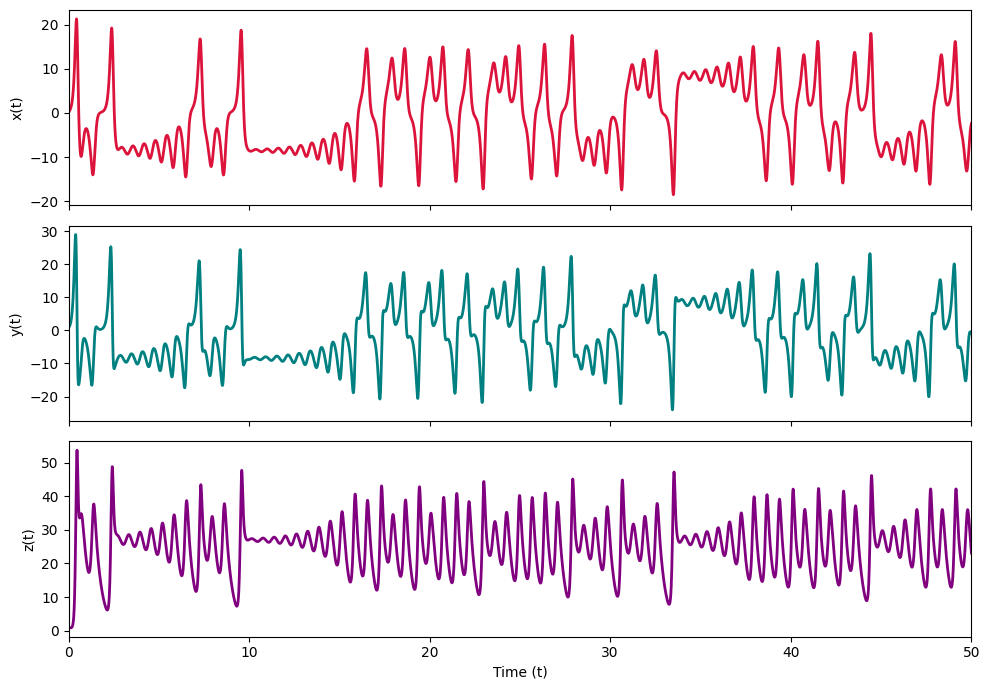

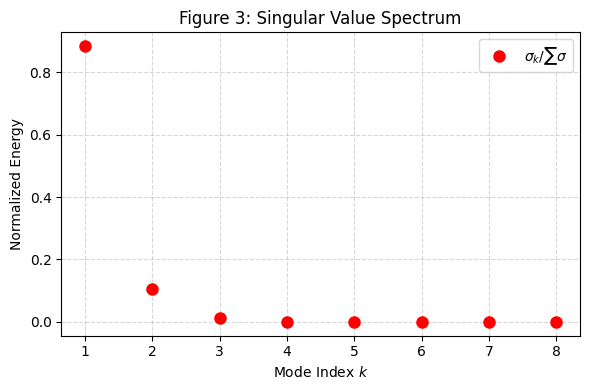

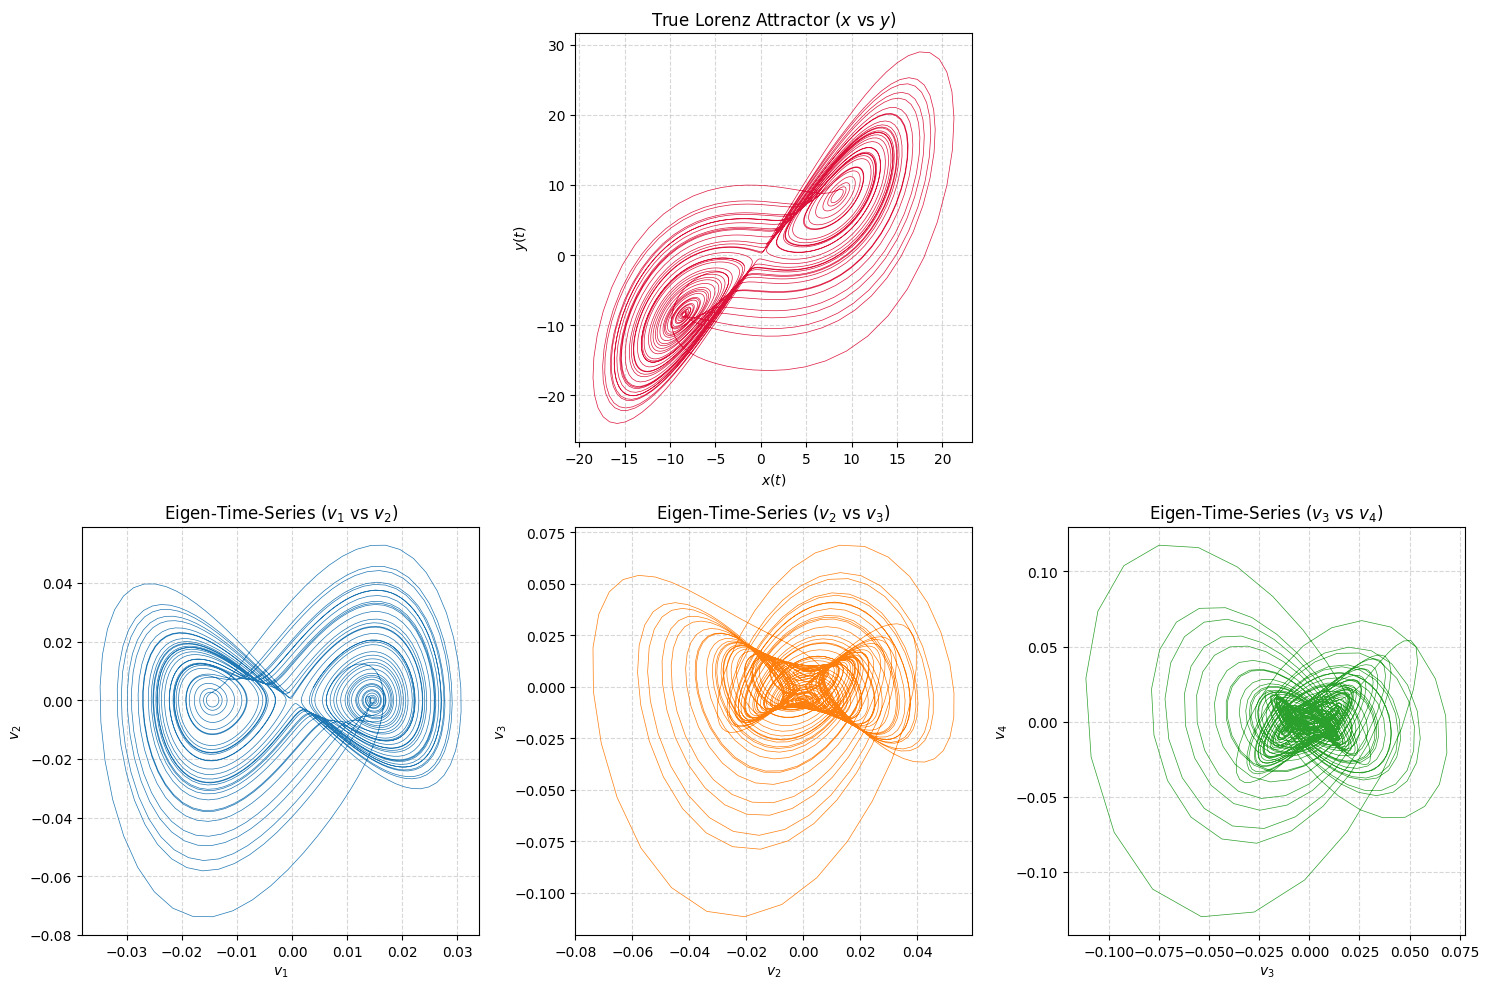

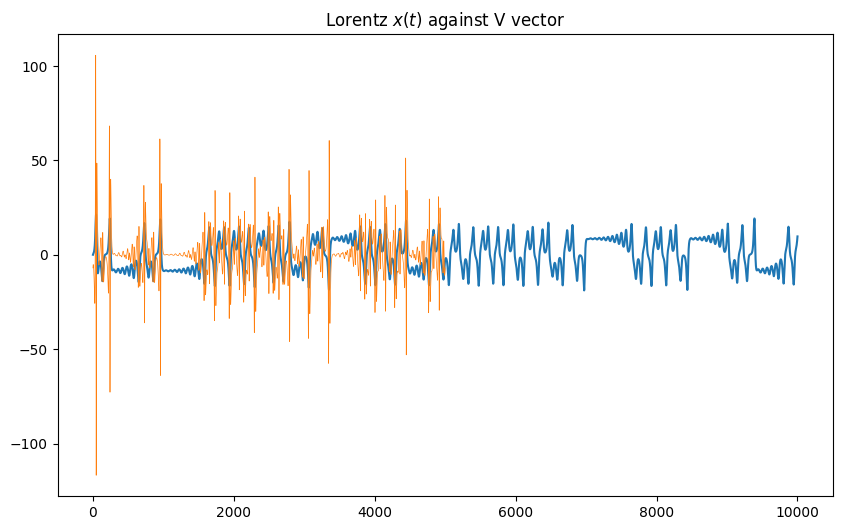

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import hankel
from scipy.linalg import svd
# %matplotlib widget

def lorentz (xyz, s=10, r=28, b=2.667) :

    """
    Parameter
    ---------
    xyz : array, shape (3,)

    s,r,b : float
    Lorentz attarractor's parameter 
    """
    x,y,z = xyz
    x_dot = s*(y-x)
    y_dot = r*x - y -x*z
    z_dot = x*y - b*z

    return np.array([x_dot, y_dot, z_dot])

def plot_lorentz ():
    dt = 0.01
    num_steps = 10000
    xyzs =np.empty((num_steps+1,3))
    xyzs[0] = (0.,1.0,1.05)

    for i in range(num_steps):
        xyzs[i+1] = xyzs[i] + lorentz(xyzs[i]) * dt

    x = xyzs[:,0]
    y = xyzs[:,1]
    z = xyzs[:,2]
    t = np.arange(num_steps + 1) * dt


    fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

    axes[0].plot(t, x, color="crimson", lw=2)
    axes[0].set_ylabel("x(t)")
    # axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, y, color="teal", lw=2)
    axes[1].set_ylabel("y(t)")
    # axes[1].grid(True, alpha=0.3)

    axes[2].plot(t, z, color="purple", lw=2)
    axes[2].set_ylabel("z(t)")
    axes[2].set_xlabel("Time (t)")
    # axes[2].grid(True, alpha=0.3)

    plt.xlim(0, 50)
    plt.tight_layout()
    # plt.show()

    return x,y,z,t

def truncuate_Hankel (m_dim , n_dim, trunc_rank, time_series_data):

    first_col = x[:m_dim]
    last_row = x[m_dim-1:m_dim-1+n_dim]
    H = hankel(first_col, last_row)
    print("Original Hankel Matrix Shape:", H.shape)

    U,s,V = svd(H, full_matrices=False)

    new_U = U[:,:trunc_rank]
    new_s = s[:trunc_rank]
    new_V = V[:trunc_rank,:]

    return new_U, new_s, new_V

x,y,z,timestep = plot_lorentz()

U,s,V = truncuate_Hankel(m_dim=8,n_dim=5000, trunc_rank=8, time_series_data=x)



plt.figure(figsize=(6, 4))
normalized_s = s / np.sum(s)
plt.plot(
    np.arange(1, len(s) + 1),
    normalized_s,
    "ro",
    markersize=8,
    label=r"$\sigma_k / \sum \sigma$",
)
plt.title("Figure 3: Singular Value Spectrum")
plt.xlabel("Mode Index $k$")
plt.ylabel("Normalized Energy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
# plt.show()

print(f"Shape of U matrix: {U.shape}\n Shape of s matrix: {s.shape} \n Shape of V matrix: {V.shape}")

# Create a figure and a 2x3 grid layout
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3)

# Row 1, Middle (Column 1): True Lorenz Attractor
ax_true = fig.add_subplot(gs[0, 1])
ax_true.plot(x[8-1:8-1+5000], y[8-1:8-1+5000], color="crimson", lw=0.5)
ax_true.set_title("True Lorenz Attractor ($x$ vs $y$)")
ax_true.set_xlabel("$x(t)$")
ax_true.set_ylabel("$y(t)$")
ax_true.grid(True, linestyle="--", alpha=0.5)

# Row 2, Left (Column 0): v1 vs v2
ax_v12 = fig.add_subplot(gs[1, 0])
ax_v12.plot(V[0,:], V[1,:], color="tab:blue", lw=0.5)
ax_v12.set_title("Eigen-Time-Series ($v_1$ vs $v_2$)")
ax_v12.set_xlabel("$v_1$")
ax_v12.set_ylabel("$v_2$")
ax_v12.grid(True, linestyle="--", alpha=0.5)

# Row 2, Middle (Column 1): v2 vs v3
ax_v23 = fig.add_subplot(gs[1, 1])
ax_v23.plot(V[1,:], V[2,:], color="tab:orange", lw=0.5)
ax_v23.set_title("Eigen-Time-Series ($v_2$ vs $v_3$)")
ax_v23.set_xlabel("$v_2$")
ax_v23.set_ylabel("$v_3$")
ax_v23.grid(True, linestyle="--", alpha=0.5)

# Row 2, Right (Column 2): v3 vs v4
ax_v34 = fig.add_subplot(gs[1, 2])
ax_v34.plot(V[2,:], V[3,:], color="tab:green", lw=0.5)
ax_v34.set_title("Eigen-Time-Series ($v_3$ vs $v_4$)")
ax_v34.set_xlabel("$v_3$")
ax_v34.set_ylabel("$v_4$")
ax_v34.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.figure(figsize=(10,6))
plt.title("Lorentz $x(t)$ against V vector")
plt.plot(x, label="$x(t)$")
# plt.plot(500*V[0,:], lw=0.8)
# plt.plot(500*V[1,:], lw=0.8)
# plt.plot(500*V[2,:], lw=0.8)
plt.plot(900*V[3,:], lw=0.5)





plt.show()


